# 03 -- Isolation by distance

Computes linearized pairwise site-level Fst and regresses against geographic distance.

**Inputs**
- `table_S1_metadata.tsv` --> STAGdb metadata for samples included in manuscript
- `mac_ld.gt_matrix.int8.npz` from `convert_vcf_to_npz.py` --> not downsampled


**Outputs**
- `apal_ibd.tsv` --> filtered and merged sites for IBD analysis
- `lin_fst_sites_greater_antilles.tsv` --> linearized site-level pairwise Fst table for Greater Antilles
- `lin_fst_sites_florida.tsv` --> idem for Florida Reef Tract
- `ibd_greater_antilles.pdf` --> scatter linFst vs distance
- `ibd_florida.pdf`
---

## Imports and paths

In [1]:
from __future__ import annotations

import itertools
import sys
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

sys.path.insert(0, str(Path("../scripts")))

from gt_io import load_cache_npz, write_cache_npz, basic_parse_report

from popgen_utils import (
    build_symmetric_pair_matrix,
    compute_ibd_stats_from_long_df,
    dosage_to_genotype_array,
    fst_mat_to_nm_long,
    fst_pair_with_nloci,
    haversine_km,
    linearized_fst,
    mantel_test,
    order_sites_greedy_nn,
)

import plotly.express as px

from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform

from plotly.subplots import make_subplots
import plotly.graph_objects as go


In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 150)

In [3]:
PROJECT_DIR = Path(os.environ.get("APAL_PROJECT_DIR", "/path/to/your/project"))
DATA_DIR    = Path(os.environ.get("APAL_DATA_DIR",    "/path/to/your/project/datasets"))

# input
META_TSV  = PROJECT_DIR / "table_S1_metadata.tsv"

NPZ = DATA_DIR / "mac_ld.gt_matrix.int8.npz"


------

## IBD functions

In [58]:
def build_panel(apal_ibd, gt, subregion, site_merge_fn=None, site_merge_map=None):
    """
    Filter to subregion, apply site merges, align to NPZ order,
    deduplicate (one sample per MLG × site), filter by min genets,
    and return a trimmed GenotypeArray.
    """
    panel = apal_ibd[apal_ibd[IBD_COL] == subregion].copy()

    if site_merge_fn is not None:
        panel["site_merged"] = panel[SITE_COL].map(site_merge_fn)
    elif site_merge_map is not None:
        panel["site_merged"] = panel[SITE_COL].map(lambda x: site_merge_map.get(x, x))
    else:
        panel["site_merged"] = panel[SITE_COL]

    # align to NPZ sample order
    npz_lookup = {s: i for i, s in enumerate(gt.sample_ids)}
    panel = panel[panel[ID_COL].isin(npz_lookup)].copy()
    panel["_npz_idx"] = panel[ID_COL].map(npz_lookup)
    panel = panel.sort_values("_npz_idx").reset_index(drop=True)

    # deduplicate: one sample per (MLG, merged site)
    panel = (
        panel
        .drop_duplicates(subset=[MLG_COL, "site_merged"], keep="first")
        .reset_index(drop=True)
    )

    # filter sites by min_genets
    site_n = panel.groupby("site_merged")[MLG_COL].nunique()
    valid  = site_n[site_n >= MIN_GENETS_PER_SITE].index
    panel  = panel[panel["site_merged"].isin(valid)].copy().reset_index(drop=True)

    # site centroids and genet counts
    site_coords = (
        panel.groupby("site_merged")
        .agg(
            lat_median=(LAT_COL, "median"),
            lon_median=(LON_COL, "median"),
            n_genets=(MLG_COL, "nunique"),
        )
        .reset_index()
        .rename(columns={"site_merged": "site"})
    )

    # subset genotype matrix and build GenotypeArray
    G_sub = gt.G[:, panel["_npz_idx"].to_numpy()]
    gta   = dosage_to_genotype_array(G_sub)

    return panel, site_coords, gta


def compute_pairwise_fst(panel, gta):
    """Weir-Cockerham FST for all site pairs. Returns a long DataFrame."""
    sites = sorted(panel["site_merged"].unique())
    rows  = []
    for s1, s2 in itertools.combinations(sites, 2):
        mask1 = (panel["site_merged"] == s1).values
        mask2 = (panel["site_merged"] == s2).values
        fst, n_loci = fst_pair_with_nloci(gta, mask1, mask2)
        rows.append({"site1": s1, "site2": s2, "fst": fst, "n_loci": n_loci})
    return pd.DataFrame(rows)


def build_ibd_df(fst_df, site_coords_ordered, site_region=None):
    """
    Add linearized FST, geographic distance, along-tract distance,
    and optionally a pair_group column for coloring.
    """
    df            = fst_df.copy()
    df["linearized_fst"] = df["fst"].apply(linearized_fst)
    coord = site_coords_ordered.set_index("site")[["lat_median", "lon_median", "tract_km"]]

    df["geo_dist_km"] = df.apply(lambda r: haversine_km(
        coord.loc[r["site1"], "lat_median"], coord.loc[r["site1"], "lon_median"],
        coord.loc[r["site2"], "lat_median"], coord.loc[r["site2"], "lon_median"],
    ), axis=1)
    df["along_tract_km"] = df.apply(lambda r: abs(
        coord.loc[r["site1"], "tract_km"] - coord.loc[r["site2"], "tract_km"]
    ), axis=1)

    if site_region is not None:
        def _pair_group(r):
            g1 = site_region.get(r["site1"], "Unknown")
            g2 = site_region.get(r["site2"], "Unknown")
            a, b = sorted([g1, g2])
            return f"{a}–{b}"
        df["pair_group"] = df.apply(_pair_group, axis=1)
        df["pair_type"]  = df.apply(
            lambda r: "within" if
            site_region.get(r["site1"]) == site_region.get(r["site2"])
            else "between", axis=1
        )

    return df


def plot_ibd(ibd_df, x_col="geo_dist_km", y_col="linearized_fst",
             title="IBD", save_base=None, figsize=(6,4),
             hue_col=None, pair_colors=None, markers=None, ax=None):
    """
    IBD scatter with OLS regression line and annotated statistics.
    hue_col : str, optional
        Column in ibd_df to color points
    pair_colors : dict, optional
    """
    extra_cols = [c for c in [hue_col, "pair_type"]
                  if c and c in ibd_df.columns]
    cols = [x_col, y_col] + extra_cols
    df   = ibd_df[cols].dropna(subset=[x_col, y_col])
    x, y = df[x_col].values, df[y_col].values

    ols    = stats.linregress(x, y)
    r2     = ols.rvalue ** 2
    istats = compute_ibd_stats_from_long_df(
        ibd_df, x_col=x_col, y_col=y_col, n_perm=N_MANTEL_PERM
    )

    _standalone = ax is None
    if _standalone:
        fig, ax = plt.subplots(figsize=figsize)

    if hue_col is not None:
        groups = sorted(df[hue_col].unique())
        if pair_colors is None:
            cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
            _colors = {g: cycle[i % len(cycle)] for i, g in enumerate(groups)}
        else:
            _colors = {g: pair_colors[g] for g in groups if g in pair_colors}
        _has_type = "pair_type" in df.columns and markers is not None
        for grp, grp_df in df.groupby(hue_col):
            _color  = _colors.get(grp, "grey")
            _marker = "o"
            if _has_type:
                _ptype  = grp_df["pair_type"].iloc[0]
                _marker = markers.get(f"{_ptype}_region", "o")
            ax.scatter(
                grp_df[x_col], grp_df[y_col],
                s=40, edgecolors="k", linewidths=0.5, alpha=0.85,
                color=_color, marker=_marker, label=grp, zorder=3,
            )
        ax.legend(
            title="Region pair", fontsize=7, title_fontsize=8,
            bbox_to_anchor=(1.02, 1), loc="upper left",
            borderaxespad=0, framealpha=0.9,
        )
    else:
        ax.scatter(x, y, s=40, edgecolors="k", linewidths=0.5, alpha=0.8, zorder=3)

    xline = np.linspace(x.min(), x.max(), 200)
    ax.plot(xline, ols.slope * xline + ols.intercept, color="0.4", lw=1)

    label = (
        f"$R^2$ = {r2:.3f}  (p = {istats['ols_p']:.3f})\n"
        f"Mantel r = {istats['mantel_r']:.3f}  (p = {istats['mantel_p']:.3f})\n"
        f"n pairs = {istats['n_pairs']}"
    )
    if _standalone:
        ax.text(1.02, 0.0, label, transform=ax.transAxes, fontsize=8,
            ha="left", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9))
    else:
        ax.text(0.97, 0.03, label, transform=ax.transAxes, fontsize=8,
            ha="right", va="bottom",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="0.8", alpha=0.9))

    _x_labels = {
        "geo_dist_km":    "Geographic distance (km)",
        "along_tract_km": "Along-tract distance (km)",
    }
    ax.set_xlabel(_x_labels.get(x_col, x_col))
    ax.set_ylabel("$F_{ST}$ / (1 \u2212 $F_{ST}$)")
    ax.set_title(title)
    ax.grid(True, alpha=0.25)
    plt.tight_layout()

    if _standalone:
        plt.tight_layout()
        if save_base is not None:
            for ext in ("pdf", "eps"):
                plt.gcf().savefig(f"{save_base}.{ext}", bbox_inches="tight")
            print(f"Saved \u2192 {save_base}.pdf / .eps")
        plt.show()
    return istats


----
## Filter metadata to IBD sites

In [5]:
meta = pd.read_csv(META_TSV, sep="\t", low_memory=False)

In [6]:
ID_COL          = "affymetrix_id"
SPECIES_COL     = "species"
MLG_COL         = "mlg"
REGION_COL      = "region"
SUBREGION_COL   = "region_sub"
REEF_COL        = "reef"
SITE_COL        = "reef"
LAT_COL         = "lat_clean"
LON_COL         = "lon_clean"
NURSERY_COL     = "is_nursery"
FACILITY_COL    = "is_facility"
IBD_COL         = "subregion_ibd"

MIN_GENETS_PER_SITE = 5
N_MANTEL_PERM       = 10_000

REGIONAL_MAF_MIN = 0.05


In [7]:
# sites known to be nursery / restoration etc 

NURSERY_SITE_EXCLUDE: list[str] = [
    "CRF",                 # Coral Restoration Foundation
    "The Reef Institute",  # Reef Institute facility
    "Unknown",             # DARPA recruits (need to update metadata!)
]

NURSERY_SITE_PATTERNS: list[str] = [
    r"OP",    # outplanting-plot sites
    r"Outplant", 
    r"Mote",  # Mote Marine Laboratory
    r"FLAQ",  # Florida Aquarium
]


## Flag those samples in metadata and write to file

In [8]:
# flag samples in metadata (is_facility)
#   - is_nursery  : original flag
#   - name/pattern: exact reef names + regex patterns for known facilities
#   - coordinates : any sample sharing exact lat/lon with a flagged facility
# is_nursery is preserved for provenance 
# is_facility is used for filtering

_excl_pat_str = "|".join(NURSERY_SITE_PATTERNS) if NURSERY_SITE_PATTERNS else None

_nursery_mask = meta[NURSERY_COL].fillna(False).astype(bool)

_name_mask = meta[REEF_COL].isin(NURSERY_SITE_EXCLUDE)
if _excl_pat_str:
    _name_mask |= meta[REEF_COL].fillna("").str.contains(_excl_pat_str, regex=True)

_fac_coords = (
    meta.loc[_nursery_mask | _name_mask, [LAT_COL, LON_COL]]
    .dropna().drop_duplicates().reset_index(drop=True)
)
_coord_mask = (
    meta[[LAT_COL, LON_COL]]
    .merge(_fac_coords.assign(_excl=True), on=[LAT_COL, LON_COL], how="left")
    ["_excl"].fillna(False).astype(bool)
)

meta["is_facility"] = _nursery_mask | _name_mask | _coord_mask

print(f"is_facility = True : {meta['is_facility'].sum():,} samples")
print(meta.loc[meta["is_facility"], REEF_COL].value_counts().to_string())

meta.to_csv(META_TSV, sep="\t", index=False)
# print(f"Saved {META_TSV}")


is_facility = True : 1,964 samples
reef
MML International Gene Bank                         225
ReefRenewal Nursery                                 224
The Reef Institute                                  145
Unknown                                             126
Tavernier Nursery                                    96
Elbow and Brewster Batch Cross                       81
North Dry Rocks OP                                   71
MML Ex-situ Nursery IC2R3                            61
Elbow-Horseshoe-Sand Island - batch cross            57
Sombrero Reef_CREMP 2_Outplant                       46
Sombrero Reef_CREMP 1_Outplant                       46
Looe Key Bouys 10-11                                 45
Looe Key_CREMP 1_Outplant                            39
MML Looe Key Nursery                                 35
Looe Key_AP Plot 2_Outplant                          30
Looe Key_CREMP 2_Outplant                            30
Sombrero Reef_AP Plot 1_Outplant                     29
Cayo Cor

/var/folders/gy/hpdjslm952zf06gfcqfb2d5dzt2sp7/T/ipykernel_74526/4152948374.py:23: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  ["_excl"].fillna(False).astype(bool)


## This would be the new Table 1:

In [9]:
region_summary = (
    meta.loc[
        meta[SUBREGION_COL].notna()
    ]
    .groupby(SUBREGION_COL, dropna=False)
    .agg(
        sites=(REEF_COL, "nunique"),
        samples=(ID_COL, "size"),
        genets=(MLG_COL, "nunique"),
        wild_genets=(
            MLG_COL,
            lambda s: s[
                ~meta.loc[s.index, "is_facility"].fillna(False)
            ].nunique()
        ),
        facility=(FACILITY_COL, "sum"),
        latitude=(LAT_COL, "median"),
        longitude=(LON_COL, "median"),
    )
    .reset_index()
    .rename(columns={SUBREGION_COL: "region"})
)

region_summary["region"] = (
    region_summary["region"]
    .astype("string")
    .str.replace(" ", "", regex=False)
)

region_summary["latitude"] = region_summary["latitude"].round(4)
region_summary["longitude"] = region_summary["longitude"].round(4)


_sum_row = {
    "region":      "sum",
    "latitude":    float("nan"),
    "longitude":   float("nan"),
}

for col in region_summary.select_dtypes(include="number").columns:
    if col not in ("latitude", "longitude"):
        _sum_row[col] = region_summary[col].sum()

region_summary = pd.concat(
    [region_summary, pd.DataFrame([_sum_row])],
    ignore_index=True,
)

region_summary = region_summary.rename(columns={
    "wild_genets": "wild_genets",
    "facility":    "facility_samples",
})

# region_summary[["latitude", "longitude"]] = (
#     region_summary[["latitude", "longitude"]]
#     .astype(object)
#     .where(region_summary[["latitude", "longitude"]].notna(), other="")
# )

region_summary

# Table 1

,region,sites,samples,genets,wild_genets,facility_samples,latitude,longitude
0,Bahamas,12,60,51,51,0,24.0631,-76.3738
1,Belize,31,125,78,71,18,16.4657,-88.1990
2,Colombia,18,80,64,64,0,9.8147,-75.8511
3,Colombia_SanAndres,2,5,5,5,0,14.3625,-80.1614
4,Cuba,3,55,44,44,0,23.1732,-82.0993
5,Curacao,19,196,129,129,0,12.0831,-68.8956
6,DominicanRepublic,6,89,79,70,11,18.4012,-68.8466
7,Florida,199,2697,651,227,1813,25.0928,-80.4361
8,Honduras,7,43,35,30,7,16.3000,-86.5200
9,Jamaica,1,16,15,15,0,18.5228,-77.7644


---

In [10]:
apal_wild = meta.loc[
    ~meta["is_facility"]
].copy().reset_index(drop=True)

apal_wild.shape


(2040, 26)

In [11]:
_site_nursery = (
    meta.groupby([REGION_COL, REEF_COL], dropna=False)
    .agg(
        n_total  =(ID_COL,       "size"),
        n_nursery=(NURSERY_COL,  lambda s: s.fillna(False).sum()),
    )
    .reset_index()
)
_site_nursery["frac_nursery"] = (_site_nursery["n_nursery"]
                                  / _site_nursery["n_total"])
_site_nursery["n_wild"] = (_site_nursery["n_total"]
                            - _site_nursery["n_nursery"])

# Show only sites that have at least one nursery-flagged sample
_site_nursery.loc[
    _site_nursery["n_nursery"] > 0
].sort_values("frac_nursery", ascending=False).reset_index(drop=True)


,region,reef,n_total,n_nursery,frac_nursery,n_wild
0,Belize,Carne Nursery,5,5,1.0,0
1,Florida,Sombrero Reef-Outplants,18,18,1.0,0
2,Florida,MML Ex-situ Nursery IC2R8,1,1,1.0,0
3,Florida,MML Ex-situ Nursery IC2R9,1,1,1.0,0
4,Florida,MML Ex-situ Nursery Islamorada,10,10,1.0,0
5,Florida,MML Ex-situ nursery Key Largo,27,27,1.0,0
6,Florida,MML International Gene Bank,225,225,1.0,0
7,Florida,MML Looe Key Nursery,35,35,1.0,0
8,Florida,MML Sand Key Nursery,3,3,1.0,0
9,Florida,North Dry Rocks Outplant,3,3,1.0,0


In [12]:
apal_wild['subregion_ibd'] = 'Exclude'

florida_regions = ['Florida']
grant_regions = ['Dominican Republic', 'Puerto Rico', 'USVI']

apal_wild.loc[apal_wild[REGION_COL].isin(florida_regions), 'subregion_ibd'] = 'Florida'
apal_wild.loc[apal_wild[REGION_COL].isin(grant_regions), 'subregion_ibd'] = 'GreaterAntilles'

apal_wild['subregion_ibd'].value_counts(dropna=False)


subregion_ibd
Florida            884
Exclude            588
GreaterAntilles    568
Name: count, dtype: int64

In [13]:
apal_ibd = apal_wild.copy()
gt = load_cache_npz(str(NPZ))

print(f"Metadata : {len(apal_ibd):,} samples")
print(f"NPZ      : {gt.G.shape[0]:,} SNPs × {gt.G.shape[1]:,} samples")

apal_ibd[IBD_COL].value_counts()

Metadata : 2,040 samples
NPZ      : 5,555 SNPs × 955 samples


subregion_ibd
Florida            884
Exclude            588
GreaterAntilles    568
Name: count, dtype: int64

----
## Greater Antilles

In [14]:
grant_df = apal_wild.loc[
    apal_wild["subregion_ibd"] == "GreaterAntilles"
].copy().reset_index(drop=True)

In [15]:
grant_site_counts = (
    grant_df.groupby([SUBREGION_COL, REEF_COL], dropna=False)
    .agg(
        # n_rows=(ID_COL, "size"),
        n_genets=(MLG_COL, lambda s: s.nunique(dropna=True)),
        lat_clean=(LAT_COL, "median"),
        lon_clean=(LON_COL, "median"),
    )
    .reset_index()
    .sort_values(["n_genets", SUBREGION_COL, REEF_COL], ascending=[False, True, True])
    .reset_index(drop=True)
)

grant_site_counts

,region_sub,reef,n_genets,lat_clean,lon_clean
0,Dominican Republic,PuntaCana,28,18.527480,-68.357600
1,Puerto Rico,Gilligan's Reef,27,17.939170,-66.869200
2,USVI,Buck Island,19,17.780760,-64.587480
3,USVI,Rust Op Twist,17,17.782790,-64.792010
4,Dominican Republic,Catalina,16,18.376290,-69.008500
5,Dominican Republic,Minitas,16,18.401240,-68.920900
6,Puerto Rico,Cayo Lajas,15,17.937500,-66.899400
7,Puerto Rico,Cayo Coral HMO5,14,17.937620,-66.890900
8,Puerto Rico,Laurel,14,17.941900,-67.057500
9,Puerto Rico,Penon Moncho Diaz,14,18.472240,-66.478700


#### Plot site maps

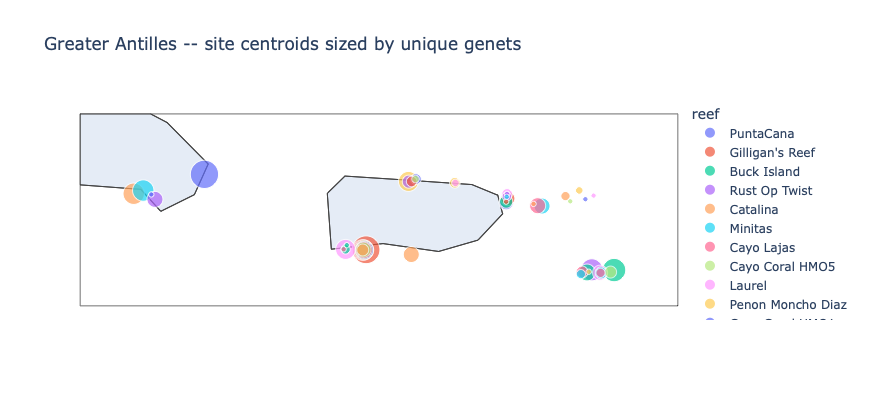

In [16]:
fig = px.scatter_geo(
    grant_site_counts,
    lat=LAT_COL,
    lon=LON_COL,
    color=REEF_COL,
    size="n_genets",
    hover_name=SUBREGION_COL,
    hover_data=[SUBREGION_COL, REEF_COL, "n_genets"],
    title="Greater Antilles -- site centroids sized by unique genets",
)

fig.update_geos(
    scope="world",
    projection_type="natural earth",
    showcountries=True,
    showcoastlines=True,
    lataxis_range=[17.5, 19.0],
    lonaxis_range=[-69.5, -64.0],
)

fig.update_layout(height=400)
fig.show()

In [17]:
grant_df["merged_site"] = grant_df[REEF_COL]

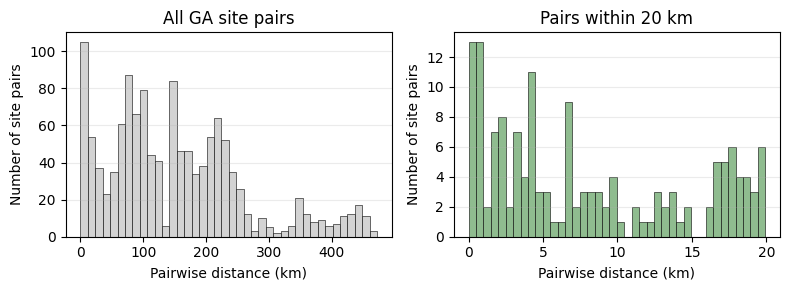

In [59]:
# MIN_GENETS_PER_SITE = 5

# explore inter-site distances for proximity-based merges
ga_site_coords_raw = (
    grant_df.groupby(REEF_COL)
    .agg(
        lat_median=(LAT_COL,      "median"),
        lon_median=(LON_COL,      "median"),
        n_genets  =(MLG_COL,      "nunique"),
        subregion =(SUBREGION_COL, "first"),
    )
    .reset_index()
    .rename(columns={REEF_COL: "site"})
)

# pairwise distances (all site pairs)
_sites = ga_site_coords_raw["site"].tolist()
_dist_rows = []
for _i, _s1 in enumerate(_sites):
    for _j, _s2 in enumerate(_sites):
        if _j <= _i:
            continue
        _r1 = ga_site_coords_raw.loc[ga_site_coords_raw["site"] == _s1].iloc[0]
        _r2 = ga_site_coords_raw.loc[ga_site_coords_raw["site"] == _s2].iloc[0]
        _d  = haversine_km(_r1["lat_median"], _r1["lon_median"],
                           _r2["lat_median"], _r2["lon_median"])
        _dist_rows.append({
            "site1":  _s1,           "n1":   int(_r1["n_genets"]),
            "site2":  _s2,           "n2":   int(_r2["n_genets"]),
            "sub1":   _r1["subregion"],       
            "sub2":   _r2["subregion"],      
            "dist_km": _d,
        })

ga_dist_df = pd.DataFrame(_dist_rows)

# distance distribution plots
fig, axes = plt.subplots(1, 2, figsize=(8,3))

axes[0].hist(ga_dist_df["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="lightgrey")
axes[0].set_xlabel("Pairwise distance (km)")
axes[0].set_ylabel("Number of site pairs")
axes[0].set_title("All GA site pairs")
axes[0].grid(True, alpha=0.25, axis="y")

_close = ga_dist_df[ga_dist_df["dist_km"] <= 20]
axes[1].hist(_close["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="darkseagreen")
axes[1].set_xlabel("Pairwise distance (km)")
axes[1].set_ylabel("Number of site pairs")
axes[1].set_title("Pairs within 20 km")
axes[1].grid(True, alpha=0.25, axis="y")

plt.tight_layout()
plt.show()

# candidate merges
PROX_THRESH_KM = 10

ga_merge_candidates = ga_dist_df[
    (ga_dist_df["sub1"] == ga_dist_df["sub2"]) &
    (ga_dist_df["dist_km"] <= PROX_THRESH_KM)
].sort_values("dist_km").reset_index(drop=True)


In [20]:
ga_merge_candidates.sort_values(
    ["sub1", "dist_km"], ascending=[True, True]
)[["sub1", "site1", "n1", "site2", "n2", "dist_km"]].reset_index(drop=True)

,sub1,site1,n1,site2,n2,dist_km
0,Dominican Republic,Reef Balls,9,Sombrero,1,5.568270
1,Dominican Republic,Minitas,16,Sombrero,1,8.538613
2,Dominican Republic,Catalina,16,Minitas,16,9.650665
3,Puerto Rico,Laurel,14,San Cristobal,3,0.000000
4,Puerto Rico,Cayo Largo,1,Cayo Largo North,6,0.000000
5,Puerto Rico,Cayo Largo South,4,Lobos,1,0.000000
6,Puerto Rico,Cayo Lajas,15,Coral Uberbs,5,0.000000
7,Puerto Rico,Cayo Largo Norte,7,Cayo Largo North,6,0.011071
8,Puerto Rico,Cayo Largo,1,Cayo Largo Norte,7,0.011071
9,Puerto Rico,Cayo Coral HMO4,10,Cayo Coral HMO5,14,0.117132


In [21]:
_pair_rows = []
for _idx, _row in ga_merge_candidates.iterrows():
    _label = f"{_row['site1']} ↔ {_row['site2']}"
    for _site, _partner in ((_row['site1'], _row['site2']),
                             (_row['site2'], _row['site1'])):
        _info = ga_site_coords_raw.loc[ga_site_coords_raw['site'] == _site].iloc[0]
        _pair_rows.append({
            'site':       _site,
            'subregion':  _row['sub1'],
            'pair_label': _label,
            'partner':    _partner,
            'dist_km':    round(float(_row['dist_km']), 1),
            'n_genets':   int(_info['n_genets']),
            'lat':        _info['lat_median'],
            'lon':        _info['lon_median'],
        })

_merge_plot_df = (
    pd.DataFrame(_pair_rows)
    .drop_duplicates(subset=['site', 'pair_label'])
    .reset_index(drop=True)
)
print(f"{len(_merge_plot_df)} rows | {_merge_plot_df['pair_label'].nunique()} candidate pairs")


202 rows | 101 candidate pairs


## Plot candidate merge maps

In [23]:
# build distance matrix
_site_list = ga_site_coords_raw["site"].tolist()
_n         = len(_site_list)
_dist_mat  = np.zeros((_n, _n))

for _i in range(_n):
    for _j in range(_i + 1, _n):
        _r1, _r2 = ga_site_coords_raw.iloc[_i], ga_site_coords_raw.iloc[_j]
        _d = haversine_km(_r1["lat_median"], _r1["lon_median"],
                          _r2["lat_median"], _r2["lon_median"])
        _dist_mat[_i, _j] = _dist_mat[_j, _i] = _d

# complete linkage clustering
PROX_THRESH_KM = 10

_Z       = linkage(squareform(_dist_mat), method="complete")
_labels  = fcluster(_Z, t=PROX_THRESH_KM, criterion="distance")

ga_site_coords_raw["prox_cluster"] = _labels

# proximity merge map from clusters that have > 1 site
_cluster_sizes = ga_site_coords_raw.groupby("prox_cluster")["site"].count()
_multi_clusters = _cluster_sizes[_cluster_sizes > 1].index

GA_PROX_MERGE_MAP = {}
for _cl in _multi_clusters:
    _members = ga_site_coords_raw.loc[
        ga_site_coords_raw["prox_cluster"] == _cl, "site"
    ].tolist()
    # canonical name = member with the most genets
    _canonical = ga_site_coords_raw.loc[
        ga_site_coords_raw["site"].isin(_members)
    ].sort_values("n_genets", ascending=False).iloc[0]["site"]
    for _s in _members:
        GA_PROX_MERGE_MAP[_s] = _canonical

print(f"{len(_multi_clusters)} proximity clusters --> {len(GA_PROX_MERGE_MAP)} sites remapped")
GA_PROX_MERGE_MAP

14 proximity clusters --> 48 sites remapped


{'Reef Balls': 'Reef Balls',
 'Sombrero': 'Reef Balls',
 'Catalina': 'Catalina',
 'Minitas': 'Catalina',
 'Dominos East': 'Dominos East',
 'Waimea': 'Dominos East',
 'El Eco': 'Penon Moncho Diaz',
 'Los Tubos': 'Penon Moncho Diaz',
 'Penon Moncho Diaz': 'Penon Moncho Diaz',
 'Playita': 'Penon Moncho Diaz',
 'Tractores': 'Penon Moncho Diaz',
 'Cayo Coral HMO1': "Gilligan's Reef",
 'Cayo Coral HMO4': "Gilligan's Reef",
 'Cayo Coral HMO5': "Gilligan's Reef",
 'Cayo Coral HMO9': "Gilligan's Reef",
 'Cayo Lajas': "Gilligan's Reef",
 'Coral Uberbs': "Gilligan's Reef",
 "Gilligan's Reef": "Gilligan's Reef",
 'La Parguera': 'Laurel',
 'Laurel': 'Laurel',
 'San Cristobal': 'Laurel',
 'San Cristobal Forereef': 'Laurel',
 'Cayo Largo': 'Cayo Largo Norte',
 'Cayo Largo Norte': 'Cayo Largo Norte',
 'Cayo Largo North': 'Cayo Largo Norte',
 'Cayo Largo South': 'Cayo Largo Norte',
 'Cayo Largo Sur': 'Cayo Largo Norte',
 'Lobos': 'Cayo Largo Norte',
 'Noemi': 'Cayo Largo Norte',
 'Palomino (Sand Slide 

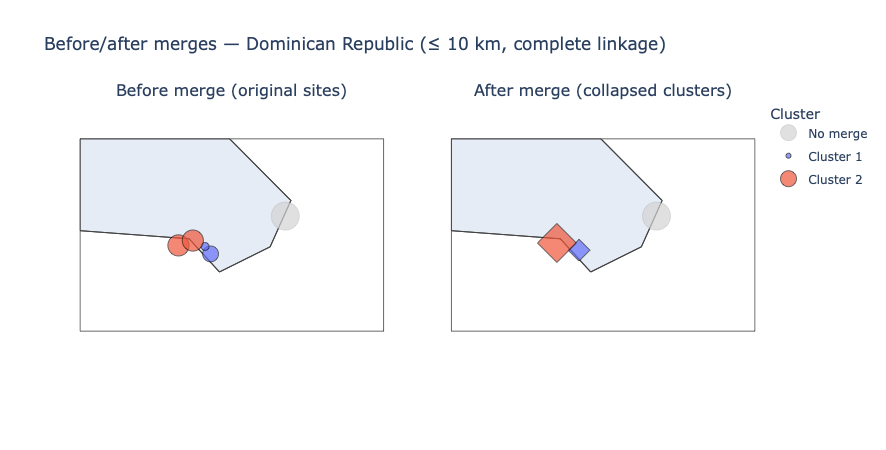

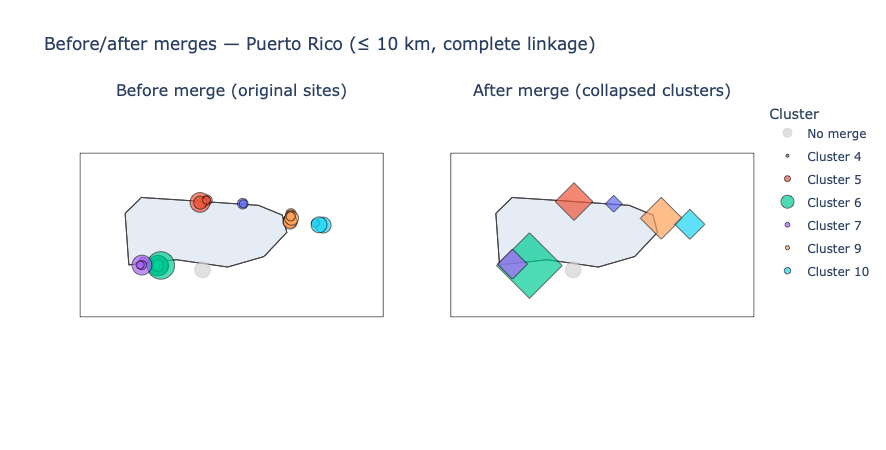

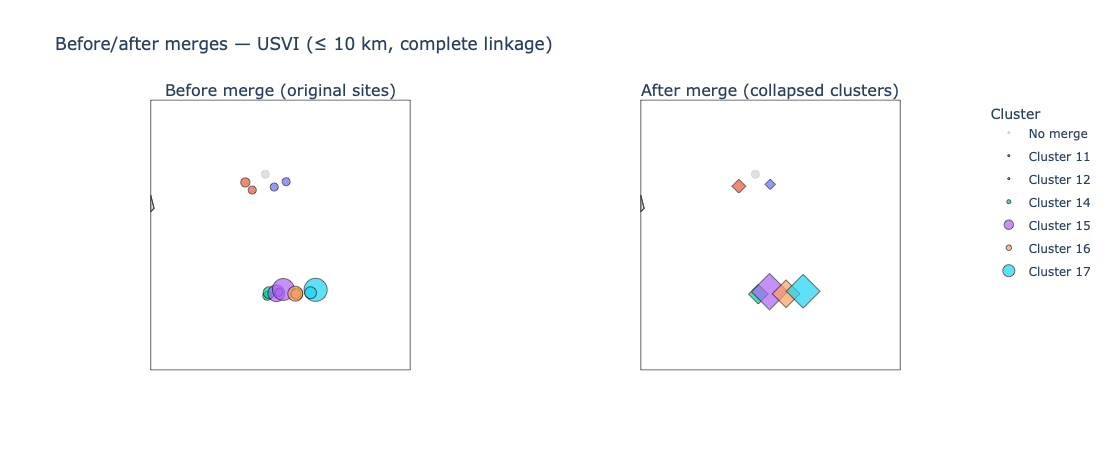

In [24]:
_max_genets = ga_site_coords_raw['n_genets'].max()
_sizeref    = 2 * _max_genets / (28 ** 2)
_PAD_LAT, _PAD_LON = 0.4, 0.6

for _sub in sorted(ga_site_coords_raw['subregion'].unique()):
    _sub_df    = ga_site_coords_raw[ga_site_coords_raw['subregion'] == _sub].copy()
    _cl_sizes  = _sub_df.groupby('prox_cluster')['site'].count()
    _multi_cls = sorted(_cl_sizes[_cl_sizes > 1].index)
    _single_cl = set(_cl_sizes[_cl_sizes == 1].index)
    _singletons = _sub_df[_sub_df['prox_cluster'].isin(_single_cl)]

    _clr_cycle = px.colors.qualitative.Plotly
    _cl_color  = {cl: _clr_cycle[i % len(_clr_cycle)]
                  for i, cl in enumerate(_multi_cls)}

    _lat_range = [_sub_df['lat_median'].min() - _PAD_LAT,
                  _sub_df['lat_median'].max() + _PAD_LAT]
    _lon_range = [_sub_df['lon_median'].min() - _PAD_LON,
                  _sub_df['lon_median'].max() + _PAD_LON]
    _geo_cfg = dict(
        scope='world', projection_type='natural earth',
        showcountries=True, showcoastlines=True,
        lataxis_range=_lat_range, lonaxis_range=_lon_range,
    )

    fig = make_subplots(
        rows=1, cols=2,
        specs=[[{'type': 'geo'}, {'type': 'geo'}]],
        subplot_titles=['Before merge (original sites)',
                         'After merge (collapsed clusters)'],
    )

    # non-merged trace
    def _singleton_trace(col, show_legend):
        fig.add_trace(go.Scattergeo(
            lat=_singletons['lat_median'],
            lon=_singletons['lon_median'],
            mode='markers',
            marker=dict(
                size=_singletons['n_genets'],
                sizemode='area', sizeref=_sizeref, sizemin=4,
                color='lightgrey',
                line=dict(width=0.5, color='darkgrey'),
            ),
            text=_singletons['site'],
            customdata=_singletons['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>no merge</extra>',
            name='No merge', legendgroup='singleton', showlegend=show_legend,
        ), row=1, col=col)

    _singleton_trace(col=1, show_legend=True)
    _singleton_trace(col=2, show_legend=False)

    # ── left panel: original sites, colored by cluster ────────────────────────
    for _cl in _multi_cls:
        _cl_df   = _sub_df[_sub_df['prox_cluster'] == _cl]
        _cl_name = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=_cl_df['lat_median'],
            lon=_cl_df['lon_median'],
            mode='markers',
            marker=dict(
                size=_cl_df['n_genets'],
                sizemode='area', sizeref=_sizeref, sizemin=4,
                color=_cl_color[_cl],
                line=dict(width=0.8, color='black'),
            ),
            text=_cl_df['site'],
            customdata=_cl_df['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>' + _cl_name + '</extra>',
            name=_cl_name, legendgroup=_cl_name, showlegend=True,
        ), row=1, col=1)

    # right panel: collapsed centroids (diamond markers)
    for _cl in _multi_cls:
        _cl_df     = _sub_df[_sub_df['prox_cluster'] == _cl]
        _canonical = GA_PROX_MERGE_MAP[_cl_df.iloc[0]['site']]
        _total_n   = int(_cl_df['n_genets'].sum())
        _members   = ', '.join(_cl_df['site'].tolist())
        _cl_name   = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=[_cl_df['lat_median'].mean()],
            lon=[_cl_df['lon_median'].mean()],
            mode='markers',
            marker=dict(
                size=[_total_n],
                sizemode='area', sizeref=_sizeref, sizemin=4,
                color=_cl_color[_cl],
                line=dict(width=0.8, color='black'),
                symbol='diamond',
            ),
            text=[_canonical],
            customdata=[[_total_n, len(_cl_df), _members]],
            hovertemplate=(
                '<b>%{text}</b> (merged)<br>'
                'Total genets: %{customdata[0]}<br>'
                'Sites merged: %{customdata[1]}<br>'
                'Members: %{customdata[2]}'
                '<extra></extra>'
            ),
            name=_cl_name, legendgroup=_cl_name, showlegend=False,
        ), row=1, col=2)

    fig.update_layout(
        geo=_geo_cfg, geo2=_geo_cfg,
        title_text=f'Before/after merges — {_sub} (≤ {PROX_THRESH_KM} km, complete linkage)',
        height=450, width=980,
        legend=dict(title='Cluster', tracegroupgap=4),
    )
    fig.show()


In [25]:
ga_panel, ga_sites, ga_gta = build_panel(
    apal_ibd, gt,
    subregion="GreaterAntilles",
    site_merge_map=GA_PROX_MERGE_MAP,
)

print(f"{ga_panel['site_merged'].nunique()} sites | {ga_panel[MLG_COL].nunique()} genets")
ga_sites.sort_values("n_genets", ascending=False)


14 sites | 305 genets


,site,lat_median,lon_median,n_genets
5,Gilligan's Reef,17.93762,-66.889800,77
9,Penon Moncho Diaz,18.47224,-66.475300,30
10,PuntaCana,18.52748,-68.357600,28
1,Buck Island,17.78094,-64.590065,24
3,Cayo Largo Norte,18.31450,-65.579000,24
12,Rust Op Twist,17.78260,-64.792505,24
2,Catalina,18.40124,-68.920900,21
8,Los Corchos,18.28283,-65.289600,19
7,Laurel,17.94190,-67.057500,17
13,Sugar Beach,17.75957,-64.713610,16


In [27]:
# regional MAF filter (Greater Antilles)
_ac    = ga_gta.count_alleles()
_total = _ac.sum(axis=1)
_alt_f = np.where(_total > 0, _ac[:, 1] / _total, 0.0)
_maf   = np.minimum(_alt_f, 1.0 - _alt_f)
_maf_mask = (_maf >= REGIONAL_MAF_MIN) & (_total > 0)
ga_gta = ga_gta.compress(_maf_mask, axis=0)
print(f"Regional MAF > {REGIONAL_MAF_MIN} (Greater Antilles): "
      f"{_maf_mask.sum():,} / {len(_maf_mask):,} loci retained")


Regional MAF > 0.05 (Greater Antilles): 3,162 / 3,162 loci retained


In [28]:
ga_fst_df = compute_pairwise_fst(ga_panel, ga_gta)
print(f"{len(ga_fst_df)} site pairs | FST range: "
      f"{ga_fst_df['fst'].min():.4f} \u2013 {ga_fst_df['fst'].max():.4f}")
ga_fst_df.head()


91 site pairs | FST range: -0.0022 – 0.0631


,site1,site2,fst,n_loci
0,Berberia Bank,Buck Island,0.037524,3140
1,Berberia Bank,Catalina,0.045667,3120
2,Berberia Bank,Cayo Largo Norte,0.005680,3131
3,Berberia Bank,Dominos East,0.000599,3065
4,Berberia Bank,Gilligan's Reef,0.006384,3141


In [29]:
ga_sites_ordered = order_sites_greedy_nn(ga_sites)

# region label per merged site (Dominican Republic / Puerto Rico / USVI)
# used for coloring site pairs in the IBD scatter
ga_site_region = (
    ga_panel.groupby("site_merged")[REGION_COL]
    .first()
    .to_dict()
)

ga_ibd_df = build_ibd_df(ga_fst_df, ga_sites_ordered, site_region=ga_site_region)
ga_ibd_df.head()


,site1,site2,fst,n_loci,linearized_fst,geo_dist_km,along_tract_km,pair_group,pair_type
0,Berberia Bank,Buck Island,0.037524,3140,0.038987,197.645896,294.981870,Puerto Rico–USVI,between
1,Berberia Bank,Catalina,0.045667,3120,0.047853,266.598409,282.532330,Dominican Republic–Puerto Rico,between
2,Berberia Bank,Cayo Largo Norte,0.005680,3131,0.005712,103.123943,160.622018,Puerto Rico–Puerto Rico,within
3,Berberia Bank,Dominos East,0.000599,3065,0.000600,75.309550,108.168097,Puerto Rico–Puerto Rico,within
4,Berberia Bank,Gilligan's Reef,0.006384,3141,0.006425,46.381593,46.381593,Puerto Rico–Puerto Rico,within


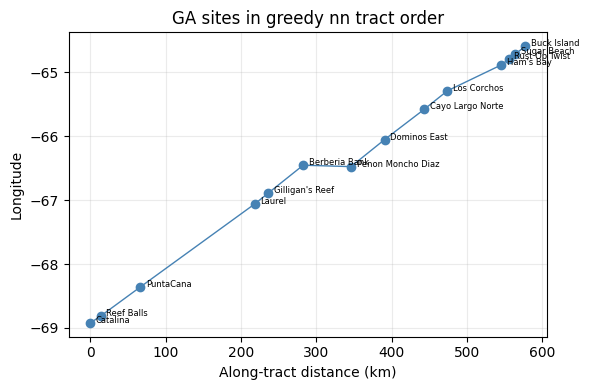

,site,tract_km,n_genets
0,Catalina,0.000000,21
1,Reef Balls,13.736069,5
2,PuntaCana,66.442707,28
3,Laurel,218.403585,17
4,Gilligan's Reef,236.150736,77
5,Berberia Bank,282.532330,8
6,Penon Moncho Diaz,345.966092,30
7,Dominos East,390.700427,6
8,Cayo Largo Norte,443.154347,24
9,Los Corchos,473.909192,19


In [30]:
# GA along-tract ordering visualization
fig, ax = plt.subplots(figsize=(6, 4))

# left: sites positioned along the tract (tract_km vs longitude)
ax.plot(ga_sites_ordered["tract_km"], ga_sites_ordered["lon_median"],
        "o-", color="steelblue", ms=6, lw=1)
for _, _row in ga_sites_ordered.iterrows():
    ax.annotate(
        _row["site"],
        (_row["tract_km"], _row["lon_median"]),
        fontsize=6, xytext=(4, 0), textcoords="offset points",
    )
ax.set_xlabel("Along-tract distance (km)")
ax.set_ylabel("Longitude")
ax.set_title("GA sites in greedy nn tract order")
ax.grid(True, alpha=0.25)

plt.tight_layout()
plt.show()

ga_sites_ordered[["site", "tract_km", "n_genets"]]


In [31]:
IBD_MARKERS = {
    "within_region":  "^",
    "between_region": "o",
}

IBD_PAIR_COLORS = {
    "Cuba–Cuba":                              "#72B7B2",
    "Cuba–Dominican Republic":               "#8FBF8F",
    "Cuba–Jamaica":                          "#76A5AF",
    "Cuba–Puerto Rico":                      "#C2A5CF",
    "Cuba–USVI":                             "#86BCB6",
    "Dominican Republic–Dominican Republic": "#4C78A8",
    "Dominican Republic–Jamaica":            "#A0CBE8",
    "Dominican Republic–Puerto Rico":        "#F2A65A",
    "Dominican Republic–USVI":               "#54A24B",
    "Jamaica–Jamaica":                       "#ECA82C",
    "Jamaica–Puerto Rico":                   "#FFBE7D",
    "Jamaica–USVI":                          "#B6992D",
    "Puerto Rico–Puerto Rico":               "#E45756",
    "Puerto Rico–USVI":                      "#B279A2",
    "USVI–USVI":                             "#9D755D",
}

# report which pairs are present / missing
_present = set(ga_ibd_df["pair_group"].unique())
_missing = [k for k in IBD_PAIR_COLORS if k not in _present]
_unknown = [g for g in _present if g not in IBD_PAIR_COLORS]
if _missing: print(f"Not in data (ignored): {_missing}")
if _unknown: print(f"In data but no color assigned: {_unknown}")


Not in data (ignored): ['Cuba–Cuba', 'Cuba–Dominican Republic', 'Cuba–Jamaica', 'Cuba–Puerto Rico', 'Cuba–USVI', 'Dominican Republic–Jamaica', 'Jamaica–Jamaica', 'Jamaica–Puerto Rico', 'Jamaica–USVI']


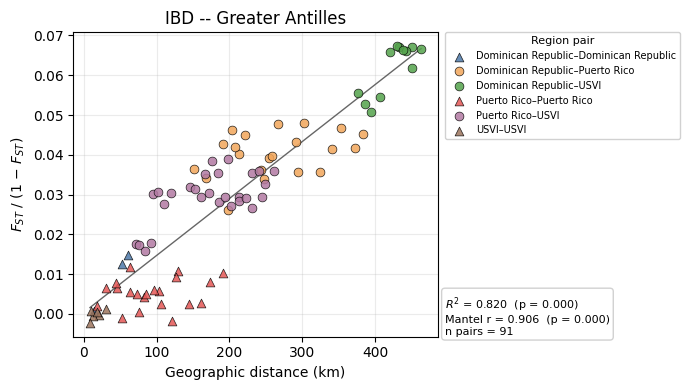

{'x_col': 'geo_dist_km',
 'n_pairs': 91,
 'slope': np.float64(0.00014328473987861126),
 'intercept': np.float64(0.00035883874653987874),
 'ols_r2': np.float64(0.8202819062638331),
 'ols_p': np.float64(6.271035929966949e-35),
 'mantel_r': 0.9056941571324357,
 'mantel_p': 9.999000099990002e-05}

In [32]:
save_ga = "/Users/kidelu001/awi-work/science/projects/apal_popgen/output/plots/ibd/ibd_grant_mac_maf"
ga_stats = plot_ibd(
    ga_ibd_df,
    figsize=(7,4),
    x_col="geo_dist_km",
    title="IBD -- Greater Antilles",
    hue_col="pair_group",
    pair_colors=IBD_PAIR_COLORS,
    markers=IBD_MARKERS,
    # save_base=save_ga,
)
ga_stats


---

*

*

*

---
## Florida panel

In [33]:
FL_SITE_MERGE_MAP = {
    # Sand Key
    "Sand Key":           "Sand Key",
    # Sand Island
    "Sand Island":        "Sand Island",
    "SI3":                "Sand Island",
    # Sambo Reef
    "Sambo":              "Sambo",
    # Elbow Reef
    "Elbow":              "Elbow",
    "EL2":                "Elbow",
    # Looe Key
    "Looe":               "Looe",
    # Biscayne Bay
    "Biscayne":           "Biscayne",
    # Conch Reef
    "Conch":              "Conch",
    "CRF":                "Conch",
    # Fowey Rocks
    "Fowey":              "Fowey",
    # French Reef
    "French":             "French Reef",
    "FR2":                "French Reef",
    # Grecian Rocks
    "Grecian":            "Grecian Rocks",
    "GR1":                "Grecian Rocks",
    # Horseshoe Reef
    "Horseshoe":          "Horseshoe",
    # Brewster Reef
    "Brew":               "Brewster",
    # Marker 3
    "Marker3":            "Marker3",
    "Marker 3":           "Marker3",
    # Ball Buoy
    "Ball Buoy":          "Ball Buoy",
    "Ball Paul":          "Ball Buoy",
    # Carysfort Reef
    "Carysfort":          "Carysfort",
    "CF2":                "Carysfort",
    # Molasses Reef
    "Molasses":           "Molasses",
    "ML3":                "Molasses",
    # Snapper Ledge
    "Snapledge":          "Snapper Ledge",
    "Snapper Ledge":      "Snapper Ledge",
    # Dry Rocks
    "KL4":                "Dry Rocks",
    "Dry Rocks":          "Dry Rocks",
    # Triple A
    "Triple A":           "Triple A",
    # Watson
    "Watson":             "Watson",
    # Turtle Rocks
    "Trtlrks":            "Turtle Rocks",
    "Turtle Rocks":       "Turtle Rocks",
    # Mote Marine
    "Mote":               "Mote",
}

_fl_raw = apal_wild.loc[apal_wild[IBD_COL] == "Florida", REEF_COL].dropna().unique()
_unmapped = sorted(s for s in _fl_raw if s not in FL_SITE_MERGE_MAP)

In [34]:
florida_df = apal_wild.loc[
    apal_wild[IBD_COL] == "Florida"
].copy().reset_index(drop=True)

# apply name harmonization so site counts and proximity analysis use clean labels
florida_df["site_harmonized"] = florida_df[REEF_COL].map(
    lambda x: FL_SITE_MERGE_MAP.get(x, x)
)

print(f"{len(florida_df):,} Florida samples, "
      f"{florida_df['site_harmonized'].nunique()} harmonized sites")


884 Florida samples, 120 harmonized sites


In [35]:
# apal_wild should have no is_facility=True rows
print("is_facility breakdown in apal_wild:")
print(apal_wild["is_facility"].value_counts(dropna=False).to_string())


is_facility breakdown in apal_wild:
is_facility
False    2040


In [36]:
fl_site_counts = (
    florida_df.groupby([SUBREGION_COL, "site_harmonized"], dropna=False)
    .agg(
        n_genets=(MLG_COL,  lambda s: s.nunique(dropna=True)),
        lat_clean=(LAT_COL, "median"),
        lon_clean=(LON_COL, "median"),
    )
    .reset_index()
    .sort_values(["n_genets", SUBREGION_COL], ascending=[False, True])
    .reset_index(drop=True)
)
fl_site_counts


,region_sub,site_harmonized,n_genets,lat_clean,lon_clean
0,Florida,Elbow Reef,33,25.142911,-80.258254
1,Florida,Key Biscayne A3,24,25.676555,-80.098518
2,Florida,Looe Key,18,24.546930,-81.407700
3,Florida,Sombrero Reef,18,24.625820,-81.110400
4,Florida,Key Biscayne C2,16,25.676555,-80.098518
5,Florida,French Reef,14,25.034950,-80.349020
6,Florida,Molasses Reef,12,25.009708,-80.374333
7,Florida,Carysfort Reef,10,25.221944,-80.210564
8,Florida,Pickles Reef,10,24.984974,-80.418316
9,Florida,Sand Island,9,25.018239,-80.368478


In [37]:
print(f"Total FL wild genets : {florida_df[MLG_COL].nunique():,}")
print(f"Total FL wild samples: {len(florida_df):,}")
print(f"Sites                : {florida_df['site_harmonized'].nunique()}")

Total FL wild genets : 227
Total FL wild samples: 884
Sites                : 120


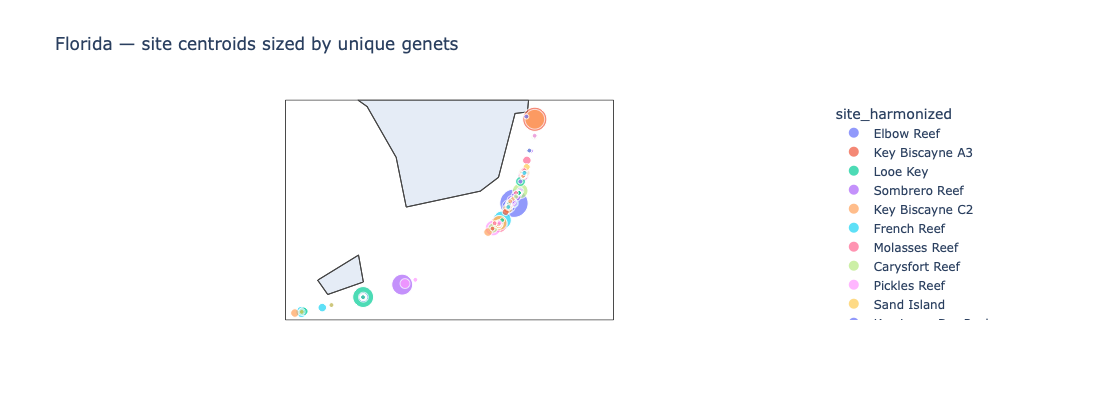

In [38]:
fig = px.scatter_geo(
    fl_site_counts,
    lat="lat_clean",
    lon="lon_clean",
    color="site_harmonized",
    size="n_genets",
    hover_name=SUBREGION_COL,
    hover_data=[SUBREGION_COL, "site_harmonized", "n_genets"],
    title="Florida — site centroids sized by unique genets",
)
fig.update_geos(
    scope="world", projection_type="natural earth",
    showcountries=True, showcoastlines=True,
    lataxis_range=[24.4, 25.8], lonaxis_range=[-82.0, -79.5],
)
fig.update_layout(height=400)
fig.show()


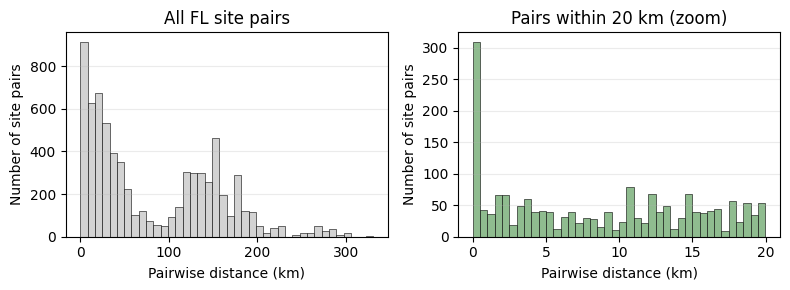

Candidate proximity merges (≤ 10 km, same subregion):


In [39]:
fl_site_coords_raw = (
    florida_df.groupby("site_harmonized")
    .agg(
        lat_median=(LAT_COL,       "median"),
        lon_median=(LON_COL,       "median"),
        n_genets  =(MLG_COL,       "nunique"),
        subregion =(SUBREGION_COL, "first"),
    )
    .reset_index()
    .rename(columns={"site_harmonized": "site"})
)

# pairwise distances
_fl_sites = fl_site_coords_raw["site"].tolist()
_fl_dist_rows = []
for _i, _s1 in enumerate(_fl_sites):
    for _j, _s2 in enumerate(_fl_sites):
        if _j <= _i:
            continue
        _r1 = fl_site_coords_raw.loc[fl_site_coords_raw["site"] == _s1].iloc[0]
        _r2 = fl_site_coords_raw.loc[fl_site_coords_raw["site"] == _s2].iloc[0]
        _d  = haversine_km(_r1["lat_median"], _r1["lon_median"],
                           _r2["lat_median"], _r2["lon_median"])
        _fl_dist_rows.append({
            "site1": _s1, "n1": int(_r1["n_genets"]),
            "site2": _s2, "n2": int(_r2["n_genets"]),
            "sub1":  _r1["subregion"],
            "sub2":  _r2["subregion"],
            "dist_km": _d,
        })

fl_dist_df = pd.DataFrame(_fl_dist_rows)

# distance distribution plots
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
axes[0].hist(fl_dist_df["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="lightgrey")
axes[0].set_xlabel("Pairwise distance (km)")
axes[0].set_ylabel("Number of site pairs")
axes[0].set_title("All FL site pairs")
axes[0].grid(True, alpha=0.25, axis="y")

_fl_close = fl_dist_df[fl_dist_df["dist_km"] <= 20]
axes[1].hist(_fl_close["dist_km"], bins=40, edgecolor="k", linewidth=0.4, color="darkseagreen")
axes[1].set_xlabel("Pairwise distance (km)")
axes[1].set_ylabel("Number of site pairs")
axes[1].set_title("Pairs within 20 km")
axes[1].grid(True, alpha=0.25, axis="y")
plt.tight_layout()
plt.show()

# candidate merges
FL_PROX_THRESH_KM = 10  # adjust after inspecting histogram

fl_merge_candidates = fl_dist_df[
    (fl_dist_df["sub1"] == fl_dist_df["sub2"]) &
    (fl_dist_df["dist_km"] <= FL_PROX_THRESH_KM)
].sort_values("dist_km").reset_index(drop=True)


In [40]:
# assign Upper / Middle / Lower Keys section to each FL site
# coords from Manzello 2012 (doi:10.1371/journal.pone.0041715)

keys_refs = pd.DataFrame({
    "keys_section": ["Upper Keys", "Upper Keys",
                     "Middle Keys", "Middle Keys",
                     "Lower Keys",  "Lower Keys"],
    "lat": [24.93898, 24.94650, 24.81216, 24.76724, 24.59723, 24.55141],
    "lon": [-80.56272, -80.50207, -80.76075, -80.75227, -81.45505, -81.40251],
})

keys_section_centroids = (
    keys_refs.groupby("keys_section", as_index=False)
    .agg(lat_ref=("lat", "mean"), lon_ref=("lon", "mean"))
)

def assign_keys_section(lat, lon, ref_df=keys_section_centroids):
    dists = ref_df.apply(
        lambda r: haversine_km(lat, lon, r["lat_ref"], r["lon_ref"]),
        axis=1,
    )
    return ref_df.loc[dists.idxmin(), "keys_section"]

# add to fl_site_coords_raw (already has lat_median / lon_median)
fl_site_coords_raw["keys_section"] = fl_site_coords_raw.apply(
    lambda r: assign_keys_section(r["lat_median"], r["lon_median"]),
    axis=1,
)

fl_site_coords_raw[['site', 'keys_section', 'lat_median', 'lon_median', 'n_genets']]\
    .sort_values(['keys_section', 'lon_median'])


,site,keys_section,lat_median,lon_median,n_genets
1,Acropolis,Lower Keys,24.680200,-82.891200,1
29,DryTortugas2,Lower Keys,24.620900,-82.867500,1
116,Western Dry Rocks,Lower Keys,24.445290,-81.927200,3
100,Sand Key,Lower Keys,24.452260,-81.877366,5
101,Sand Key - N. of Buoy 3,Lower Keys,24.452760,-81.875530,1
102,Sand Key N of Buoy 3,Lower Keys,24.452760,-81.875530,2
96,RockKey,Lower Keys,24.456020,-81.859600,3
117,Western Sambo,Lower Keys,24.479870,-81.718700,3
30,East of Eastern Sambo,Lower Keys,24.495870,-81.649030,1
92,Patch east of Eastern Sambo,Lower Keys,24.495870,-81.649030,1


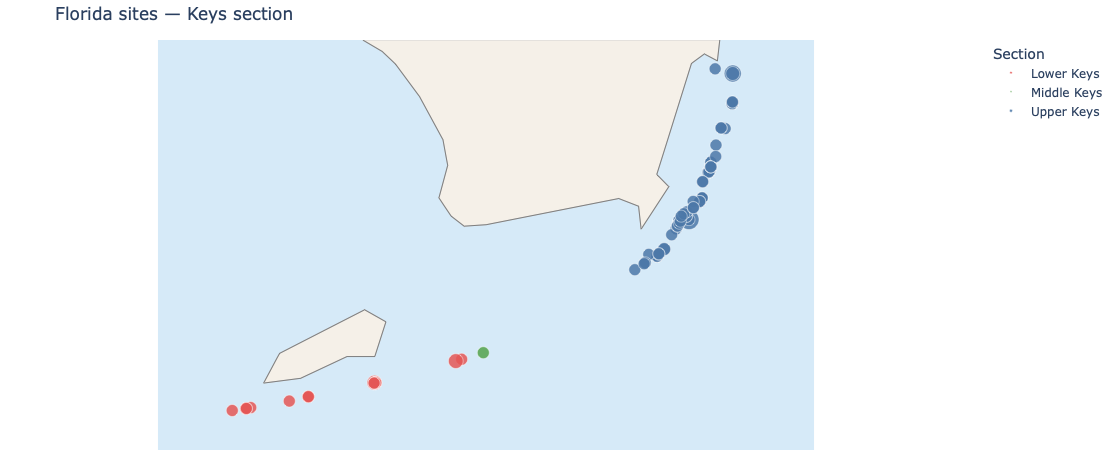

In [41]:
_section_colors = {
    "Upper Keys":  "#4C78A8",
    "Middle Keys": "#54A24B",
    "Lower Keys":  "#E45756",
}

fig = go.Figure()
for _sec, _grp in fl_site_coords_raw.groupby("keys_section"):
    fig.add_trace(go.Scattergeo(
        lat=_grp["lat_median"],
        lon=_grp["lon_median"],
        mode="markers",
        name=_sec,
        marker=dict(
            size=_grp["n_genets"],
            sizemode="area",
            sizeref=2 * fl_site_coords_raw["n_genets"].max() / (20 ** 2),
            sizemin=6,
            color=_section_colors.get(_sec, "grey"),
            opacity=0.85,
            line=dict(width=0.5, color="white"),
        ),
        text=_grp["site"],
        customdata=_grp[["n_genets", "keys_section"]].values,
        hovertemplate=(
            "<b>%{text}</b><br>"
            "Section : %{customdata[1]}<br>"
            "Genets  : %{customdata[0]}<br>"
            "Lat/Lon : %{lat:.4f}, %{lon:.4f}"
            "<extra></extra>"
        ),
    ))

fig.update_geos(
    visible=False,
    resolution=50,
    showcountries=True, countrycolor="lightgrey",
    showcoastlines=True, coastlinecolor="grey",
    showland=True, landcolor="#f5f0e8",
    showocean=True, oceancolor="#d6eaf8",
    lataxis_range=[24.3, 25.8],
    lonaxis_range=[-82.2, -79.8],
)
fig.update_layout(
    title="Florida sites — Keys section",
    legend_title="Section",
    margin=dict(l=0, r=0, t=40, b=0),
    height=450,
)
fig.show()


In [42]:
fl_merge_candidates.sort_values(
    ["sub1", "dist_km"], ascending=[True, True]
)[["sub1", "site1", "n1", "site2", "n2", "dist_km"]].reset_index(drop=True)


,sub1,site1,n1,site2,n2,dist_km
0,Florida,Looe - East of Buoy 13,1,Looe Key E. of Buoy 13,2,0.000000
1,Florida,Brewap West,1,Brewster Reef,2,0.000000
2,Florida,Brewap West,1,Brewster West,1,0.000000
3,Florida,Brewster Reef,2,Brewster West,1,0.000000
4,Florida,Patch east of Eastern Sambo,1,patch E. of Eastern Sambo,1,0.000000
...,...,...,...,...,...,...
993,Florida,ConchReef,3,Molasses SPA,1,9.904537
994,Florida,ConchReef,3,Man Key,1,9.937786
995,Florida,Carysfort Reef South,1,ConchReef,3,9.937786
996,Florida,ConchReef,3,Molasses Reef,12,9.948041


In [43]:
_fl_pair_rows = []
for _idx, _row in fl_merge_candidates.iterrows():
    _label = f"{_row['site1']} ↔ {_row['site2']}"
    for _site, _partner in ((_row['site1'], _row['site2']),
                             (_row['site2'], _row['site1'])):
        _info = fl_site_coords_raw.loc[fl_site_coords_raw['site'] == _site].iloc[0]
        _fl_pair_rows.append({
            'site':       _site,
            'subregion':  _row['sub1'],
            'pair_label': _label,
            'partner':    _partner,
            'dist_km':    round(float(_row['dist_km']), 1),
            'n_genets':   int(_info['n_genets']),
            'lat':        _info['lat_median'],
            'lon':        _info['lon_median'],
        })

fl_merge_plot_df = (
    pd.DataFrame(_fl_pair_rows)
    .drop_duplicates(subset=['site', 'pair_label'])
    .reset_index(drop=True)
)
print(f"{len(fl_merge_plot_df)} rows | {fl_merge_plot_df['pair_label'].nunique()} candidate pairs")
fl_merge_plot_df


1996 rows | 998 candidate pairs


,site,subregion,pair_label,partner,dist_km,n_genets,lat,lon
0,Looe - East of Buoy 13,Florida,Looe - East of Buoy 13 ↔ Looe Key E. of Buoy 13,Looe Key E. of Buoy 13,0.0,1,24.545780,-81.406080
1,Looe Key E. of Buoy 13,Florida,Looe - East of Buoy 13 ↔ Looe Key E. of Buoy 13,Looe - East of Buoy 13,0.0,2,24.545780,-81.406080
2,Brewap West,Florida,Brewap West ↔ Brewster Reef,Brewster Reef,0.0,1,25.566750,-80.100600
3,Brewster Reef,Florida,Brewap West ↔ Brewster Reef,Brewap West,0.0,2,25.566750,-80.100600
4,Brewap West,Florida,Brewap West ↔ Brewster West,Brewster West,0.0,1,25.566750,-80.100600
...,...,...,...,...,...,...,...,...
1991,ConchReef,Florida,Carysfort Reef South ↔ ConchReef,Carysfort Reef South,9.9,3,24.959782,-80.456236
1992,ConchReef,Florida,ConchReef ↔ Molasses Reef,Molasses Reef,9.9,3,24.959782,-80.456236
1993,Molasses Reef,Florida,ConchReef ↔ Molasses Reef,ConchReef,9.9,12,25.009708,-80.374333
1994,Carysfort,Florida,Carysfort ↔ Elbow Reef,Elbow Reef,10.0,1,25.221790,-80.210600


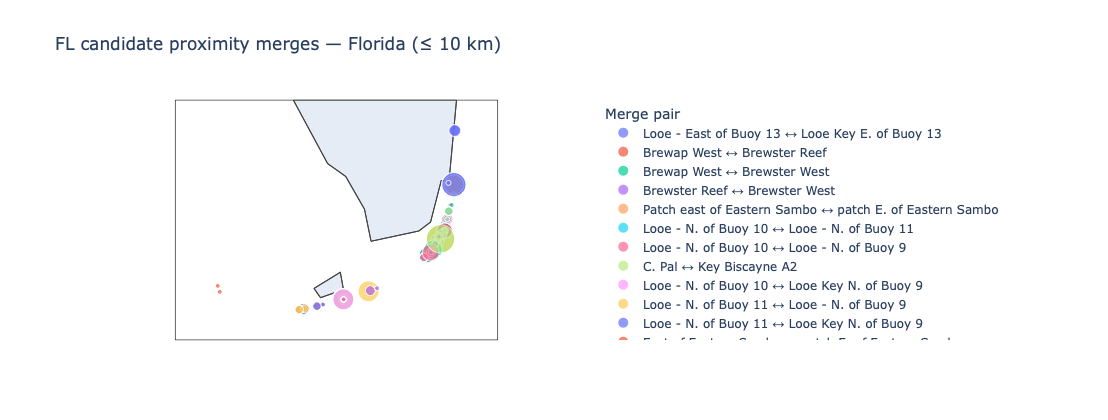

In [44]:
_PAD_LAT, _PAD_LON = 0.3, 0.5

for _sub in sorted(fl_merge_plot_df['subregion'].unique()):
    _sub_df = fl_merge_plot_df[fl_merge_plot_df['subregion'] == _sub]
    _lat_range = [_sub_df['lat'].min() - _PAD_LAT, _sub_df['lat'].max() + _PAD_LAT]
    _lon_range = [_sub_df['lon'].min() - _PAD_LON, _sub_df['lon'].max() + _PAD_LON]
    fig = px.scatter_geo(
        _sub_df,
        lat='lat', lon='lon', color='pair_label', size='n_genets',
        hover_name='site',
        hover_data={'n_genets': True, 'partner': True, 'dist_km': True,
                    'lat': False, 'lon': False},
        labels={'pair_label': 'Merge pair', 'n_genets': 'Genets',
                'partner': 'Merge partner', 'dist_km': 'Distance (km)'},
        title=f'FL candidate proximity merges — {_sub} (< {FL_PROX_THRESH_KM} km)',
    )
    fig.update_geos(
        scope='world', projection_type='natural earth',
        showcountries=True, showcoastlines=True,
        lataxis_range=_lat_range, lonaxis_range=_lon_range,
    )
    fig.update_layout(height=420)
    fig.show()


In [45]:
_fl_site_list = fl_site_coords_raw['site'].tolist()
_fl_n         = len(_fl_site_list)
_fl_dist_mat  = np.zeros((_fl_n, _fl_n))

for _i in range(_fl_n):
    for _j in range(_i + 1, _fl_n):
        _r1, _r2 = fl_site_coords_raw.iloc[_i], fl_site_coords_raw.iloc[_j]
        _d = haversine_km(_r1['lat_median'], _r1['lon_median'],
                          _r2['lat_median'], _r2['lon_median'])
        _fl_dist_mat[_i, _j] = _fl_dist_mat[_j, _i] = _d

_fl_Z      = linkage(squareform(_fl_dist_mat), method='complete')
_fl_labels = fcluster(_fl_Z, t=FL_PROX_THRESH_KM, criterion='distance')
fl_site_coords_raw['prox_cluster'] = _fl_labels

_fl_cl_sizes   = fl_site_coords_raw.groupby('prox_cluster')['site'].count()
_fl_multi_cls  = _fl_cl_sizes[_fl_cl_sizes > 1].index

FL_PROX_MERGE_MAP = {}
for _cl in _fl_multi_cls:
    _members   = fl_site_coords_raw.loc[
        fl_site_coords_raw['prox_cluster'] == _cl, 'site'].tolist()
    _canonical = fl_site_coords_raw.loc[
        fl_site_coords_raw['site'].isin(_members)
    ].sort_values('n_genets', ascending=False).iloc[0]['site']
    for _s in _members:
        FL_PROX_MERGE_MAP[_s] = _canonical

print(f'{len(_fl_multi_cls)} proximity clusters → {len(FL_PROX_MERGE_MAP)} sites remapped')
FL_PROX_MERGE_MAP


16 proximity clusters → 119 sites remapped


{'Broward County': 'NOVA',
 'NOVA': 'NOVA',
 'Conch Reef': 'Pickles Reef',
 'ConchReef': 'Pickles Reef',
 'Pickles Reef': 'Pickles Reef',
 'Snapper Ledge': 'Pickles Reef',
 'Between Pickles and Molasses': 'French Reef',
 'Carysfort Reef South': 'French Reef',
 'French Reef': 'French Reef',
 'Man Key': 'French Reef',
 'Molasses': 'French Reef',
 'Molasses Reef': 'French Reef',
 'Molasses SPA': 'French Reef',
 'MolassesReef': 'French Reef',
 'Phillips': 'French Reef',
 'Phils Reef': 'French Reef',
 'Sand Island': 'French Reef',
 'Sand Island Blue x M13': 'French Reef',
 'Grecian Rocks': 'Key Largo Dry Rocks',
 'Horseshoe': 'Key Largo Dry Rocks',
 'Horseshoe Mooring': 'Key Largo Dry Rocks',
 'Horseshoe North': 'Key Largo Dry Rocks',
 'Horseshoe Reef': 'Key Largo Dry Rocks',
 'Horseshoe Reef - Key Largo': 'Key Largo Dry Rocks',
 'Horseshoe Reef Key Largo': 'Key Largo Dry Rocks',
 'KL4NOAA': 'Key Largo Dry Rocks',
 'Key Largo Dry Rocks': 'Key Largo Dry Rocks',
 'Little Grecian': 'Key Largo 

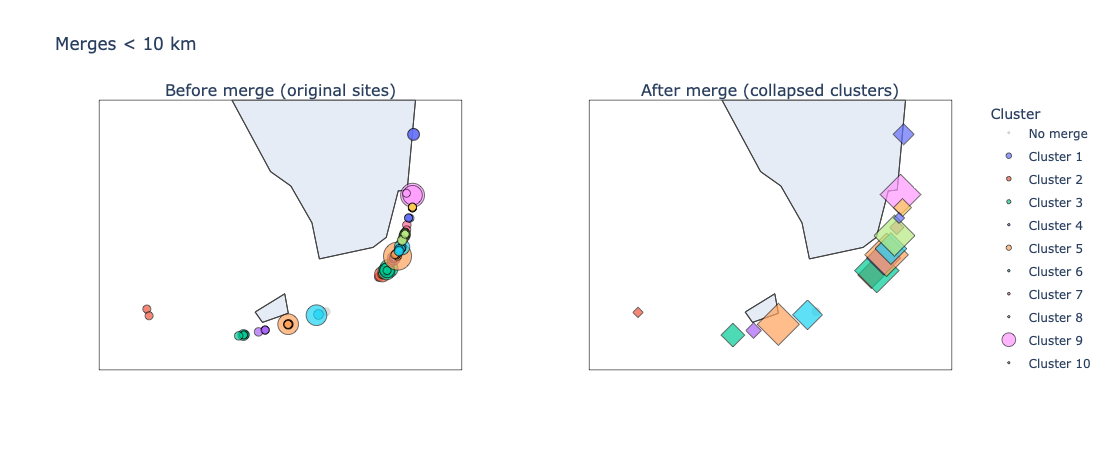

In [46]:
_max_genets_fl = fl_site_coords_raw['n_genets'].max()
_sizeref_fl    = 2 * _max_genets_fl / (28 ** 2)
_PAD_LAT, _PAD_LON = 0.3, 0.5

for _sub in sorted(fl_site_coords_raw['subregion'].unique()):
    _sub_df    = fl_site_coords_raw[fl_site_coords_raw['subregion'] == _sub].copy()
    _cl_sizes  = _sub_df.groupby('prox_cluster')['site'].count()
    _multi_cls = sorted(_cl_sizes[_cl_sizes > 1].index)
    _single_cl = set(_cl_sizes[_cl_sizes == 1].index)
    _singletons = _sub_df[_sub_df['prox_cluster'].isin(_single_cl)]
    _clr_cycle  = px.colors.qualitative.Plotly
    _cl_color   = {cl: _clr_cycle[i % len(_clr_cycle)] for i, cl in enumerate(_multi_cls)}
    _lat_range  = [_sub_df['lat_median'].min() - _PAD_LAT,
                   _sub_df['lat_median'].max() + _PAD_LAT]
    _lon_range  = [_sub_df['lon_median'].min() - _PAD_LON,
                   _sub_df['lon_median'].max() + _PAD_LON]
    _geo_cfg = dict(scope='world', projection_type='natural earth',
                    showcountries=True, showcoastlines=True,
                    lataxis_range=_lat_range, lonaxis_range=_lon_range)
    fig = make_subplots(rows=1, cols=2,
                        specs=[[{'type': 'geo'}, {'type': 'geo'}]],
                        subplot_titles=['Before merge (original sites)',
                                        'After merge (collapsed clusters)'])
    def _fl_singleton_trace(col, show_legend):
        fig.add_trace(go.Scattergeo(
            lat=_singletons['lat_median'], lon=_singletons['lon_median'], mode='markers',
            marker=dict(size=_singletons['n_genets'], sizemode='area',
                        sizeref=_sizeref_fl, sizemin=4, color='lightgrey',
                        line=dict(width=0.5, color='darkgrey')),
            text=_singletons['site'], customdata=_singletons['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>no merge</extra>',
            name='No merge', legendgroup='singleton', showlegend=show_legend,
        ), row=1, col=col)
    _fl_singleton_trace(col=1, show_legend=True)
    _fl_singleton_trace(col=2, show_legend=False)
    for _cl in _multi_cls:
        _cl_df   = _sub_df[_sub_df['prox_cluster'] == _cl]
        _cl_name = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=_cl_df['lat_median'], lon=_cl_df['lon_median'], mode='markers',
            marker=dict(size=_cl_df['n_genets'], sizemode='area',
                        sizeref=_sizeref_fl, sizemin=4, color=_cl_color[_cl],
                        line=dict(width=0.8, color='black')),
            text=_cl_df['site'], customdata=_cl_df['n_genets'].values,
            hovertemplate='<b>%{text}</b><br>Genets: %{customdata}<extra>' + _cl_name + '</extra>',
            name=_cl_name, legendgroup=_cl_name, showlegend=True,
        ), row=1, col=1)
    for _cl in _multi_cls:
        _cl_df     = _sub_df[_sub_df['prox_cluster'] == _cl]
        _canonical = FL_PROX_MERGE_MAP[_cl_df.iloc[0]['site']]
        _total_n   = int(_cl_df['n_genets'].sum())
        _members   = ', '.join(_cl_df['site'].tolist())
        _cl_name   = f'Cluster {_cl}'
        fig.add_trace(go.Scattergeo(
            lat=[_cl_df['lat_median'].mean()], lon=[_cl_df['lon_median'].mean()],
            mode='markers',
            marker=dict(size=[_total_n], sizemode='area', sizeref=_sizeref_fl, sizemin=4,
                        color=_cl_color[_cl], line=dict(width=0.8, color='black'),
                        symbol='diamond'),
            text=[_canonical], customdata=[[_total_n, len(_cl_df), _members]],
            hovertemplate=('<b>%{text}</b> (merged)<br>Total genets: %{customdata[0]}<br>'
                           'Sites merged: %{customdata[1]}<br>Members: %{customdata[2]}'
                           '<extra></extra>'),
            name=_cl_name, legendgroup=_cl_name, showlegend=False,
        ), row=1, col=2)
    fig.update_layout(geo=_geo_cfg, geo2=_geo_cfg,
                      title_text=f'Merges < {FL_PROX_THRESH_KM} km',
                      height=450, width=980,
                      legend=dict(title='Cluster', tracegroupgap=4))
    fig.show()


In [47]:
FL_COMBINED_MAP = {}
# harmonize all known raw names, then apply proximity merge
for _raw, _harmonized in FL_SITE_MERGE_MAP.items():
    FL_COMBINED_MAP[_raw] = FL_PROX_MERGE_MAP.get(_harmonized, _harmonized)
# add any harmonized names not covered by FL_SITE_MERGE_MAP
for _site, _merged in FL_PROX_MERGE_MAP.items():
    if _site not in FL_COMBINED_MAP:
        FL_COMBINED_MAP[_site] = _merged

print(f'FL_COMBINED_MAP: {len(FL_COMBINED_MAP)} raw names → '
      f'{len(set(FL_COMBINED_MAP.values()))} canonical sites')
FL_COMBINED_MAP


FL_COMBINED_MAP: 141 raw names → 23 canonical sites


{'Sand Key': 'Sand Key',
 'Sand Island': 'French Reef',
 'SI3': 'French Reef',
 'Sambo': 'Sambo',
 'Elbow': 'Elbow Reef',
 'EL2': 'Elbow Reef',
 'Looe': 'Looe',
 'Biscayne': 'Biscayne',
 'Conch': 'Conch',
 'CRF': 'Conch',
 'Fowey': 'Brewster Reef',
 'French': 'French Reef',
 'FR2': 'French Reef',
 'Grecian': 'Key Largo Dry Rocks',
 'GR1': 'Key Largo Dry Rocks',
 'Horseshoe': 'Key Largo Dry Rocks',
 'Brew': 'Brewster Reef',
 'Marker3': 'Key Biscayne B7',
 'Marker 3': 'Key Biscayne B7',
 'Ball Buoy': 'Key Biscayne B5',
 'Ball Paul': 'Key Biscayne B5',
 'Carysfort': 'Carysfort Reef',
 'CF2': 'Carysfort Reef',
 'Molasses': 'French Reef',
 'ML3': 'French Reef',
 'Snapledge': 'Pickles Reef',
 'Snapper Ledge': 'Pickles Reef',
 'KL4': 'Dry Rocks',
 'Dry Rocks': 'Dry Rocks',
 'Triple A': 'Elbow Reef',
 'Watson': 'Watson',
 'Trtlrks': 'Key Biscayne B5',
 'Turtle Rocks': 'Key Biscayne B5',
 'Mote': 'Mote',
 'Broward County': 'NOVA',
 'NOVA': 'NOVA',
 'Conch Reef': 'Pickles Reef',
 'ConchReef': 'P

In [48]:
fl_panel, fl_sites, fl_gta = build_panel(
    apal_ibd, gt,
    subregion="Florida",
    site_merge_map=FL_COMBINED_MAP,
)

print(f"{fl_panel['site_merged'].nunique()} sites | {fl_panel[MLG_COL].nunique()} genets")
fl_sites.sort_values('lon_median')


10 sites | 139 genets


,site,lat_median,lon_median,n_genets
8,Sand Key,24.452350,-81.877200,11
5,Looe Key,24.546930,-81.407700,10
9,Sombrero Reef,24.625820,-81.110400,11
7,Pickles Reef,24.985867,-80.416825,6
2,French Reef,25.033865,-80.349410,27
4,Key Largo Dry Rocks,25.122875,-80.298299,20
1,Elbow Reef,25.143965,-80.258301,20
0,Carysfort Reef,25.210065,-80.218471,15
3,Key Biscayne B5,25.316230,-80.187905,14
6,NOVA,26.211030,-80.085100,5


In [49]:
# regional MAF filter (Florida)
_ac    = fl_gta.count_alleles()
_total = _ac.sum(axis=1)
_alt_f = np.where(_total > 0, _ac[:, 1] / _total, 0.0)
_maf   = np.minimum(_alt_f, 1.0 - _alt_f)
_maf_mask = (_maf >= REGIONAL_MAF_MIN) & (_total > 0)
fl_gta = fl_gta.compress(_maf_mask, axis=0)
print(f"Regional MAF ≥ {REGIONAL_MAF_MIN} (Florida): "
      f"{_maf_mask.sum():,} / {len(_maf_mask):,} loci retained")


Regional MAF ≥ 0.05 (Florida): 3,185 / 5,555 loci retained


In [50]:
fl_fst_df = compute_pairwise_fst(fl_panel, fl_gta)
print(f"{len(fl_fst_df)} site pairs | FST range: "
      f"{fl_fst_df['fst'].min():.4f} – {fl_fst_df['fst'].max():.4f}")
fl_fst_df.head()

45 site pairs | FST range: -0.0048 – 0.0088


,site1,site2,fst,n_loci
0,Carysfort Reef,Elbow Reef,0.000397,3181
1,Carysfort Reef,French Reef,0.000277,3183
2,Carysfort Reef,Key Biscayne B5,0.008093,3182
3,Carysfort Reef,Key Largo Dry Rocks,0.000842,3183
4,Carysfort Reef,Looe Key,0.007971,3177


In [51]:
fl_sites_ordered = order_sites_greedy_nn(fl_sites)

# Keys section (Upper / Middle / Lower) per merged site
# assigned by nearest Manzello 2012 centroid; used for IBD pair coloring
fl_site_region = (
    fl_site_coords_raw.set_index("site")["keys_section"]
    .to_dict()
)

fl_ibd_df = build_ibd_df(fl_fst_df, fl_sites_ordered, site_region=fl_site_region)
fl_ibd_df.head()


,site1,site2,fst,n_loci,linearized_fst,geo_dist_km,along_tract_km,pair_group,pair_type
0,Carysfort Reef,Elbow Reef,0.000397,3181,0.000397,8.371850,8.371850,Upper Keys–Upper Keys,within
1,Carysfort Reef,French Reef,0.000277,3183,0.000277,23.614522,24.187500,Upper Keys–Upper Keys,within
2,Carysfort Reef,Key Biscayne B5,0.008093,3182,0.008160,12.198605,12.198605,Upper Keys–Upper Keys,within
3,Carysfort Reef,Key Largo Dry Rocks,0.000842,3183,0.000843,12.591108,13.031415,Upper Keys–Upper Keys,within
4,Carysfort Reef,Looe Key,0.007971,3177,0.008035,140.813421,144.786819,Lower Keys–Upper Keys,between


,site,tract_km,n_genets
0,Sand Key,0.000000,11
1,Looe Key,48.655745,10
2,Sombrero Reef,79.970530,11
3,Pickles Reef,160.615918,6
4,French Reef,169.255064,27
5,Key Largo Dry Rocks,180.411149,20
6,Elbow Reef,185.070715,20
7,Carysfort Reef,193.442564,15
8,Key Biscayne B5,205.641169,14
9,NOVA,305.669572,5


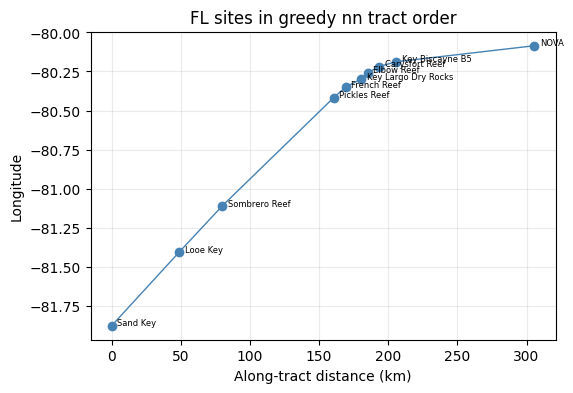

In [52]:
fig, ax = plt.subplots(figsize=(6, 4))

ax.plot(fl_sites_ordered["tract_km"], fl_sites_ordered["lon_median"],
        "o-", color="steelblue", ms=6, lw=1)
for _, _row in fl_sites_ordered.iterrows():
    ax.annotate(
        _row["site"],
        (_row["tract_km"], _row["lon_median"]),
        fontsize=6, xytext=(4, 0), textcoords="offset points",
    )
ax.set_xlabel("Along-tract distance (km)")
ax.set_ylabel("Longitude")
ax.set_title("FL sites in greedy nn tract order")
ax.grid(True, alpha=0.25)

fl_sites_ordered[["site", "tract_km", "n_genets"]]


In [53]:
FL_PAIR_COLORS = {
    "Lower Keys–Lower Keys":   "#FFBE7D",   
    "Lower Keys–Middle Keys":  "indianred",  
    "Lower Keys–Upper Keys":   "#54A24B",   
    "Middle Keys–Middle Keys": "darkseagreen",   
    "Middle Keys–Upper Keys":  "cornflowerblue",   
    "Upper Keys–Upper Keys":   "#B279A2",   
}

_fl_present = set(fl_ibd_df['pair_group'].unique())
_fl_missing = [k for k in FL_PAIR_COLORS if k not in _fl_present]
_fl_unknown = [g for g in _fl_present if g not in FL_PAIR_COLORS]
if _fl_missing: print(f'Not in data (ignored): {_fl_missing}')
if _fl_unknown: print(f'In data but no color assigned: {_fl_unknown}')


Not in data (ignored): ['Lower Keys–Middle Keys', 'Middle Keys–Middle Keys', 'Middle Keys–Upper Keys']


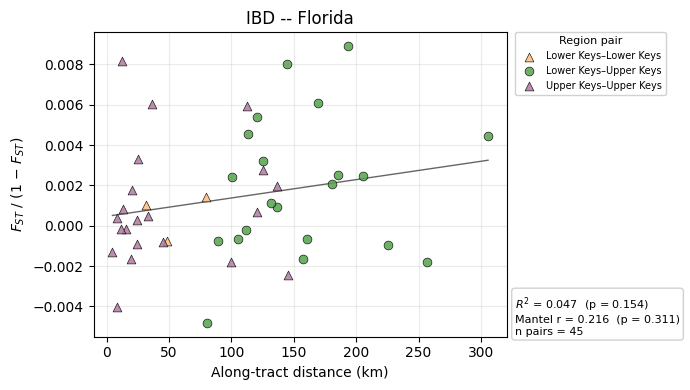

{'x_col': 'along_tract_km',
 'n_pairs': 45,
 'slope': np.float64(9.097410222437146e-06),
 'intercept': np.float64(0.00046731484072664827),
 'ols_r2': np.float64(0.046625161363386305),
 'ols_p': np.float64(0.15427254345488262),
 'mantel_r': 0.21592860246708007,
 'mantel_p': 0.31096890310968905}

In [54]:
save_fl = "/Users/kidelu001/awi-work/science/projects/apal_popgen/output/plots/ibd/ibd_fl_mac_maf"
fl_stats = plot_ibd(
    fl_ibd_df,
    figsize=(7, 4),
    x_col="along_tract_km",
    title="IBD -- Florida",
    hue_col="pair_group",
    pair_colors=FL_PAIR_COLORS,
    markers=IBD_MARKERS,
    # save_base=save_fl,
)
fl_stats


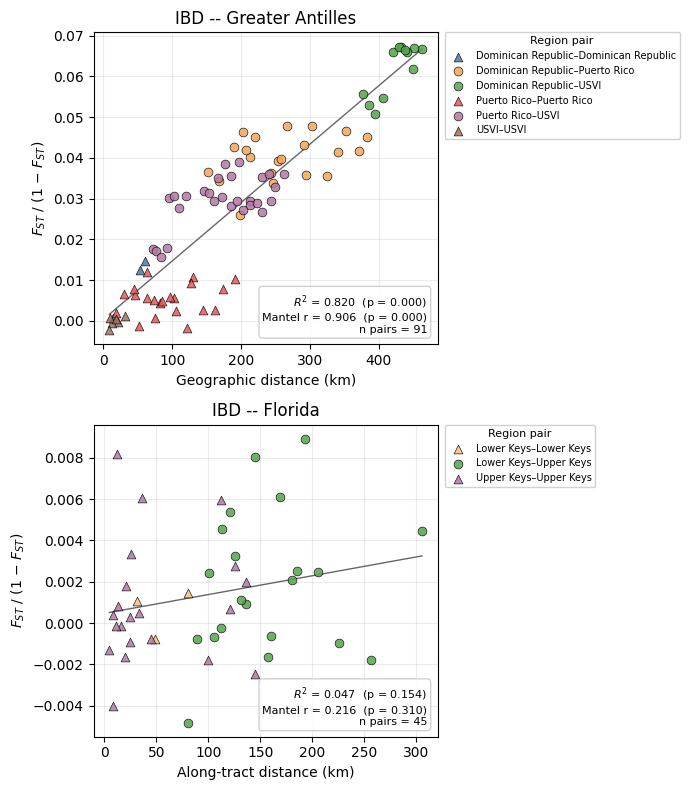

In [55]:
_SAVE_COMBINED = "/Users/kidelu001/awi-work/science/projects/apal_popgen/output/plots/ibd/ibd_combined_mac_maf"

fig, axes = plt.subplots(2, 1, figsize=(7, 8))
fig.subplots_adjust(hspace=0.5)  # room for left-panel legend

plot_ibd(
    ga_ibd_df,
    x_col="geo_dist_km",
    title="IBD -- Greater Antilles",
    hue_col="pair_group",
    pair_colors=IBD_PAIR_COLORS,
    markers=IBD_MARKERS,
    ax=axes[0],
)

plot_ibd(
    fl_ibd_df,
    x_col="along_tract_km",
    title="IBD -- Florida",
    hue_col="pair_group",
    pair_colors=FL_PAIR_COLORS,
    markers=IBD_MARKERS,
    ax=axes[1],
)

# for _ext in ("pdf", "eps"):
#     fig.savefig(f"{_SAVE_COMBINED}.{_ext}", bbox_inches="tight")
# print(f"Saved: {_SAVE_COMBINED}.pdf / .eps")

plt.show()


----
## Save IBD output tables

In [57]:
OUT_DIR = PROJECT_DIR

# final merged site assigments (sample-level)
_keep_cols = [ID_COL, MLG_COL, REGION_COL, SUBREGION_COL,
              REEF_COL, LAT_COL, LON_COL, IBD_COL, "site_merged"]
apal_ibd_out = (
    pd.concat([ga_panel, fl_panel], ignore_index=True)
    [[c for c in _keep_cols if c in ga_panel.columns]]
)
_path = OUT_DIR / "apal_ibd_samples.tsv"
apal_ibd_out.to_csv(_path, sep="\t", index=False)
# print(f"apal_ibd.tsv  : {len(apal_ibd_out):,} rows --> {_path}")

# pairwise linearized FST for GA
_path = OUT_DIR / "ibd_fst_greater_antilles.tsv"
ga_ibd_df.to_csv(_path, sep="\t", index=False)
# print(f"ibd_fst_greater_antilles.tsv : {len(ga_ibd_df)} pairs --> {_path}")

# pairwise linearized FST for FL
_path = OUT_DIR / "ibd_fst_florida.tsv"
fl_ibd_df.to_csv(_path, sep="\t", index=False)
# print(f"ibd_fst_florida.tsv          : {len(fl_ibd_df)} pairs --> {_path}")
